# Midterm Project - Writing starts after all the implementation code!

### Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Given Dataset:     10Q1 11Q1 12Q1 13Q1 14Q1 14Q3 15Q2 16Q1 16Q3 16Q4 17Q1 18Q1 19Q1 20Q1 20Q2 20Q3 21Q1 22Q1 23Q2 23Q4
quarters = np.array([1,   5,   9,   13,  17,  19,  22,  25,  27,  28,  29,  33,  37,  41,  42,  43,  45,  49,  54,  56  ])
GDP      = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1,-5.1,-28.1,33.8,6.3,-1.6, 2.4, 3.3 ])
print(len(quarters))

20


### Cubic Spline

In [2]:
h = np.diff(quarters)
dy = np.diff(GDP)
a = np.zeros_like(h)
b = np.zeros_like(h)
c = np.zeros_like(quarters)
d = np.zeros_like(h)

# Build the tridiagonal system
rhs = 3 * (dy[1:] / h[1:] - dy[:-1] / h[:-1])
low = h[1:-1].copy()
mid = 2 * (h[:-1] + h[1:])
high = h[1:-1].copy()

# Thomas algorithm
for i in range(1, len(quarters)-2):
    mid[i] -= low[i - 1] / mid[i - 1] * high[i - 1]
    rhs[i] -= low[i - 1] / mid[i - 1] * rhs[i - 1]
c[-2] = rhs[-1] / mid[-1]
for i in range(len(quarters)-4, -1, -1):
    c[i+1] = (rhs[i] - high[i] * c[i+2]) / mid[i]

# Final solution
d = np.diff(c) / (3 * h)
b = dy / h - h * (2 * c[:-1] + c[1:]) / 3
a = GDP[:-1]

# Accessibility function
def spline(x: float):
    x = x if x < max(quarters) else max(quarters)
    if x in quarters:
        return GDP[np.where(quarters == x)[0][0]]
    i: int = np.searchsorted(quarters, x, side='right') - 1
    return a[i] + b[i]*(x-quarters[i]) + c[i]*(x-quarters[i])**2 + d[i]*(x-quarters[i])**3

### Polynomial Fit with Least Squares

In [3]:
def polyfit(x, y, degree=4):
    # Vandermonde matrix
    V = np.array([[q**d for d in range(degree+1)] for q in quarters])
    coefficients = np.linalg.solve(np.dot(V.T, V), np.dot(V.T, GDP))
    
    # Accessibility function
    def poly_eval(x: float):
        return sum([c*(x**d) for c, d in zip(coefficients, range(degree+1))])
    guesses = [poly_eval(xi) for xi in x]
    return poly_eval, np.linalg.cond(V), guesses, y

### Linear fit with Least Squares

In [4]:
def linear(x, y):
    n = len(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_x2 = sum([i**2 for i in x])
    sum_xy = sum([i*j for i, j in zip(x, y)])
    
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    b = (sum_y - m * sum_x) / n
    guesses = [m*i + b for i in x]
    return m, b, guesses, y

### Error functions

In [5]:
mse = lambda y, y_pred: np.mean((y-y_pred)**2)
rsq = lambda y, y_pred: 1 - (np.sum((y-y_pred)**2) / np.sum((y-np.mean(y))**2))

# Report

### Introduction

The growth rate of the United States economy can be roughly measured by the growth rate of the Gross Domestic Product (GDP), a measure of the total value of goods and services produced within a period of time. The data used in this report is a curated selection of quarters from 2010 through 2023 and their respective seasonally adjusted annual rate (SAAR) of real GDP growth in percent, from the US Bureau of Economic Analysis (BEA). Three methods of numerical modeling will be applied to this dataset: cubic spline interpolation, polynomial fitting, and linear regression. Cubic spline interpolation is a method of fitting a smooth curve through all data points, while polynomial fitting and linear regression are least squares approximations that minimize residuals.

### Part A - Cubic Spline Interpolation

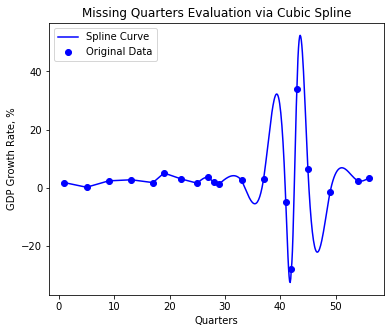

In [6]:
plt.figure(figsize=(6,5))

# Spline curve
x = np.arange(1,56.1,0.1)
y = np.array([spline(xi) for xi in x])
plt.plot(x, y, 'b-', label="Spline Curve")

# Original data
plt.plot(quarters, GDP, 'bo', label="Original Data")
plt.xlabel("Quarters")
plt.ylabel("GDP Growth Rate, %")
plt.title("Missing Quarters Evaluation via Cubic Spline")
plt.legend()
plt.show()

The cubic spline algorithm uses a set of n-1 cubic polynomials to connect n data points. The given dataset includes 20 quarters and their respective GDP growth rate, meaning this algorithm uses 19 cubic polynomials, or 19*4 = 76 unknowns. Each interior knot gives 3 conditions: the height, slope, and curvature from the polynomials on each side of the knot must match exactly. These conditions plus 2 from endpoint continuity account for all unknowns except 2, which are covered by the boundary conditions of a natural spline: that the second derivative at the end points is zero, meaning any extension of the spline curve beyond the dataset would be linear.

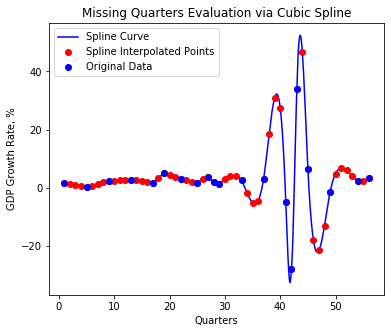

In [7]:
plt.figure(figsize=(6,5))

# Spline curve
x = np.arange(1,56.1,0.1)
y = np.array([spline(xi) for xi in x])
plt.plot(x, y, 'b-', label="Spline Curve")

# Interpolated points
x = np.arange(1,57) # 1 through 56 inclusive
y = np.array([spline(xi) for xi in x])
plt.plot(x, y, 'ro', label="Spline Interpolated Points")

# Original data
plt.plot(quarters, GDP, 'bo', label="Original Data")
plt.xlabel("Quarters")
plt.ylabel("GDP Growth Rate, %")
plt.title("Missing Quarters Evaluation via Cubic Spline")
plt.legend()
plt.show()

Up through 2017 (excluding the effects of Covid-19), the interpolant is visually smooth and a reasonable estimate of the missing GDP growth rate percentages. After 2017 however, nearly every new data point is affected by the local chaos in the data from the effects of Covid-19. This includes 2018 Q2-4 (too low), 2019 Q2-4 (way too high), 2020 Q4 (too high), 2021 Q2-4 (way too low), and 2022 Q2-2023 Q1 (slightly too high).

The Runge phenomenon is a drastic oscillation between data points, often encountered when overfitting high-degree polynomials or, in this case, when fitting a cubic spline curve to data with outliers since the curve must go through each outlier data point. This is the tradeoff between exact interpolation and numerical stability when dealing with outliers - you trade the local, high-resolution accuracy of a spline curve for the long-term, outlier-ignoring stability of a least square approximation. In datasets like this one that contain outliers, weighted least square approximations are much more preferable to cubic spline interpolations because they do not get skewed by said outliers or produce a Runge phenomenon around them.

### Part B - Polynomial & Least Squares Comparison

Polynomial:
V Condition: 18197798.182
MSE=100.630
R^2=0.004


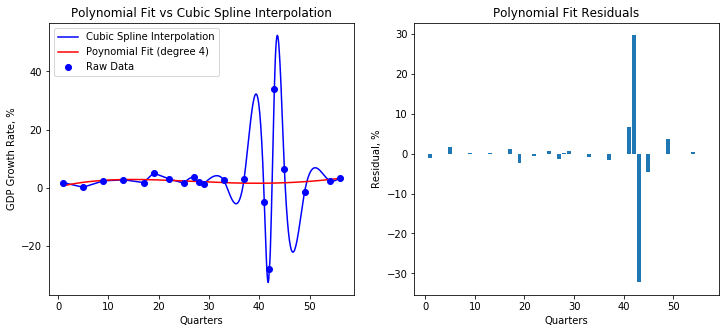

In [8]:
poly_result = polyfit(quarters, GDP)
print(f"Polynomial:\nV Condition: {poly_result[1]:.3f}")

# Main plot vs cubic spline
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
x = np.arange(1,56.1,0.1)
y = np.array([spline(xi) for xi in x])
plt.plot(x, y, 'b-', label="Cubic Spline Interpolation")
y = np.array([poly_result[0](xi) for xi in x])
plt.plot(x, y, 'r-', label="Poynomial Fit (degree 4)")
plt.plot(quarters, GDP, 'bo', label="Raw Data")
plt.xlabel("Quarters")
plt.ylabel("GDP Growth Rate, %")
plt.title("Polynomial Fit vs Cubic Spline Interpolation")
plt.legend()

# Plot residuals
plt.subplot(1,2,2)
plt.bar(quarters, poly_result[2]-poly_result[3])
plt.xlabel("Quarters")
plt.ylabel("Residual, %")
plt.title("Polynomial Fit Residuals")
print(f"MSE={mse(poly_result[3], poly_result[2]):.3f}")
print(f"R^2={rsq(poly_result[3], poly_result[2]):.3f}")
plt.show()

The polynomial fit captures the overall trend better while the cubic spline interpolation reproduces specific points better, namely the points affected by Covid-19. This is the tradeoff previously mentioned: on one hand the local, high-resolution accuracy of a cubic spline interpolation, on the other hand the long-term, outlier-ignoring stability of the polynomial fit (within the bounds of the dataset, of course).  

Linear:
Slope M=-0.001907
MSE=2.083
R^2=0.000


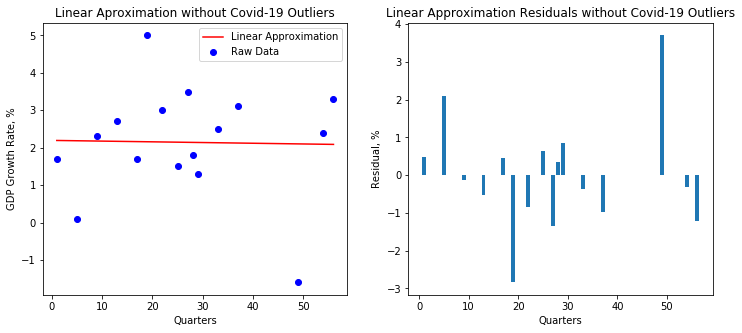

In [9]:
# Linear calculations
linear_quarters = np.concatenate((quarters[:13], quarters[-3:]))
linear_GDP = np.concatenate((GDP[:13], GDP[-3:]))
m, b, guesses, y_real = linear(linear_quarters, linear_GDP)
print(f"Linear:\nSlope M={m:.6f}")
print(f"MSE={mse(y_real, guesses):.3f}")
print(f"R^2={rsq(y_real, guesses):.3f}")

# Plot linear approximation
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(linear_quarters, m*linear_quarters + b, 'r-', label="Linear Approximation")
plt.plot(linear_quarters, linear_GDP, 'bo', label="Raw Data")
plt.xlabel("Quarters")
plt.ylabel("GDP Growth Rate, %")
plt.title("Linear Aproximation without Covid-19 Outliers")
plt.legend()

# Plot residuals
plt.subplot(1,2,2)
plt.bar(linear_quarters, guesses - y_real)
plt.xlabel("Quarters")
plt.ylabel("Residual, %")
plt.title("Linear Approximation Residuals without Covid-19 Outliers")
plt.show()

As printed, the slope of the linear approximation line is -0.001907. A linear approximation does not make sense for this data because it requires the assumption that the outliers were the only thing affected by Covid-19. From a qualitative perspective, it seems that before 2020 the data should have a substantial positive slope, which matches the intutition that the economy's rate of growth should increase under stable conditions. It seems that the data after 2021 is still affected by Covid-19, pulling the linear approximation away from the positive slope the data from before 2020 seems to have. In fact, let's test this theory, using only data up to 2019:

Linear:
Slope M=0.034313
MSE=1.216
R^2=0.097


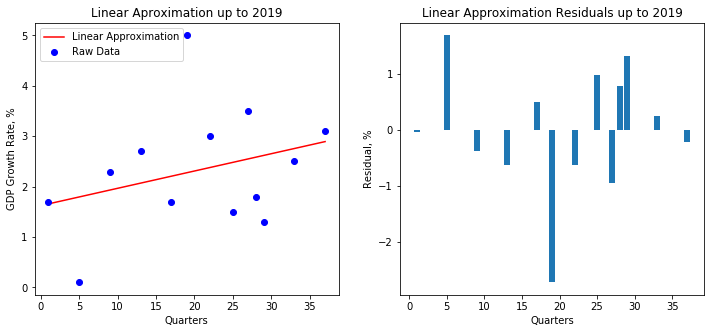

In [10]:
linear_quarters = quarters[:13]
linear_GDP = GDP[:13]
m, b, guesses, y_real = linear(linear_quarters, linear_GDP)
print(f"Linear:\nSlope M={m:.6f}")
print(f"MSE={mse(y_real, guesses):.3f}")
print(f"R^2={rsq(y_real, guesses):.3f}")

# Plot new linear approximation
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(linear_quarters, m*linear_quarters + b, 'r-', label="Linear Approximation")
plt.plot(linear_quarters, linear_GDP, 'bo', label="Raw Data")
plt.xlabel("Quarters")
plt.ylabel("GDP Growth Rate, %")
plt.title("Linear Aproximation up to 2019")
plt.legend()

# Plot residuals
plt.subplot(1,2,2)
plt.bar(linear_quarters, guesses - y_real)
plt.xlabel("Quarters")
plt.ylabel("Residual, %")
plt.title("Linear Approximation Residuals up to 2019")
plt.show()

Indeed, that matches the prediction. The linear approximation using only data up to 2019 has a slope of +0.034, much moe substantial than the previous approximation. The mean squared error decreased and the R squared value increased, meaning this is numerically a better estimate beyond plain intuition.

### Part C - Method Justification and Big O Analysis

When data points on both sides of the quarter in question are known, a cubic spline interpolation is fundamentally better than a polynomial fit approximation. This is because interpolations always go through every point, while approximations come with residual error. Take a look at the cubic spline vs polynomial graph, and imagine this quarter in question is between known quarters 41 and 42. The cubic spline would estimate about a 20% recession, while the polynomial would estimate a roughly constant GDP (0% growth) during that time. Such a quarter would certainly be affected by Covid-19 because both of its neighbors are; therefore the cubic spline interpolation is better in this case than a polynomial fit. The same can be said without any outliers or external effects present as well - no matter how close the polynomial is to the two points on either side of the quarter in question, the cubic spline will always have a better estimate because it goes directly through both points. Because of its high accuracy, low smoothness, and high sensitivity to outliers compared to a polynomial fit, the cubic spline is the clear choice for this policymaker.

Big O notation is a tool used to classify algorithms by their runtime normalized by input size, written as O(f(n)). It is calculated by either plugging a range of data set sizes and fitting a line to the output times or simply counting the number of loops in the function. The function of n in big O notation provides an upper bound on the time required to compute using a certain amount of data, and often ignores constants in favor of the overall behavior (for example, O(4n-2) would reduce to O(n)). For this reason all three methods reduce to O(n) complexity - even though the spline has more internal O(n) operations, it never has any higher complexity ones due to the optimization of the Thomas algorithm. All the O(n) operations add together and the constant can be removed, meaning it has the same fundamental complexity as a polynomial fit or a linear approximation, both of which also have only O(n) operations or simpler. Also of note is the fact that the polynomial degree is fixed in this report; if the degree were also an input, the polynomial complexity would technically become O(n*d^2). From this big O analysis, it is clear that complexity should not be a factor in the final recommendation, because they all have the same fundamental complexity of O(n).

### Conclusion

The cubic spline interpolation method proved best for interpolation with a mean squared error of 0.0 and an R squared value of 1.0, while the polynomial and linear fits using least square approximation techniques were better at analyzing the overall trend given the right data. On another note, both the cubic spline and polynomial will diverge from the data beyond what was given; they are only accurate within the dataset, while a linear approximation can be extrapolated beyond the input data but may require further input to get the intended line. Overall, with the big O complexity analysis in mind, I would recommend a polynomial fit for general trend analysis, a cubic spline interpolation for, well, interpolation, and a linear approximation only when extrapolating a trend beyond the dataset is required.